# Loading required libraries

In [1]:
library(ggplot2)
library(patchwork)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(broom)
library(circlize)
library(survminer)
library(survival)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new Inte

## Figures and Files Setup

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_5"

## Color palettes

In [3]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)
gvsm2_colors = c(
    "Granulocyte-dominant" = "#B85AA6",
    "M2 Macrophage-dominant" = "#66A61E"
)

## Loading required data

In [4]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [25]:
distances_scimap <- read_csv(file.path(data_dir, "distances_to_tumor_cells_scimap.csv"), show_col_types = FALSE) %>%
    mutate(cell_group = case_when(
        cell_category %in% myeloid ~ "Myeloid",
        cell_category %in% lymphoid ~ "Lymphoid",
        cell_category == "Tumor cells" ~ "Tumor",
        TRUE ~ "Non-immune"
    )) %>%
    filter(!cell_group %in% c("Tumor", "Non-immune"))    

In [5]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

In [23]:
distances_scimap_cellcat <- distances_scimap %>%
    group_by(patient_exp, patient_ID, cell_category) %>%
    summarise(median_distance_um = median(`Tumor cells`, na.rm = TRUE)) %>%
    ungroup() %>%
    group_by(patient_ID, cell_category) %>%
    summarise(median_distance_um = median(median_distance_um, na.rm = TRUE)) %>%
    ungroup() %>%
    complete(patient_ID, cell_category) %>%
    left_join(., survival_df) 

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, and
  cell_category.
ℹ Output is grouped by patient_exp and patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.
Joining with `by = join_by(patient_ID)`


In [7]:
distances <- read_csv(file.path("/Users/jawadalaaedeen/Desktop/PhD/NMC/results", "cell_distances_to_tumor_contour.csv"), show_col_types = FALSE) %>%
    mutate(cell_group = case_when(
        cell_category %in% myeloid ~ "Myeloid",
        cell_category %in% lymphoid ~ "Lymphoid",
        cell_category == "Tumor cells" ~ "Tumor",
        TRUE ~ "Non-immune"
    ))

    averaged_distances <- distances %>%
    # filter(tumor_signed_dist_to_contour_um >= 0) %>%
    group_by(patient_ID, patient_exp, cell_group) %>%
    summarise(avg_distance = median(tumor_signed_dist_to_contour_um)) %>%
    group_by(patient_ID, cell_group) %>%
    summarise(avg_distance = median(avg_distance)) %>%
    filter(!cell_group %in% c("Tumor", "Non-immune"))

averaged_distances_pivot <- averaged_distances %>%
    pivot_wider(names_from = cell_group, values_from = avg_distance)

plot_df <- averaged_distances_pivot %>%
  select(patient_ID, Myeloid, Lymphoid) %>%
  drop_na(Myeloid, Lymphoid) %>%
  pivot_longer(cols = c(Myeloid, Lymphoid),
               names_to = "cell_group",
               values_to = "median_distance_um")



`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, patient_exp, and cell_group.
ℹ Output is grouped by patient_ID and patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, patient_exp, cell_group))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_group.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [9]:
enrich_df <- read_csv(file.path(data_dir, "layer_enrichment_results.csv"), show_col_types = FALSE)
enrich_df

patient_ID,tumor_layer,cell_type,layer_proportion,global_proportion,fold_enrichment,log2_fold_enrichment,diff
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NUT_1,stroma 0-25 µm,Actin+ cells,0.0871135793,0.0458263187,1.7393835,0.77016394,4.128726e-02
NUT_1,stroma 0-25 µm,B cells,0.0025460498,0.0025694590,0.9622332,-0.05681163,-2.340920e-05
NUT_1,stroma 0-25 µm,CD4+ T cells,0.0099471930,0.0055026332,1.8180396,0.85601624,4.444560e-03
NUT_1,stroma 0-25 µm,CD8+ T cells,0.0168690295,0.0121758193,1.3073331,0.37924157,4.693210e-03
NUT_1,stroma 0-25 µm,DCs,0.0001717033,0.0002534020,0.6914063,0.46760555,-8.169868e-05
NUT_1,stroma 0-25 µm,Endothelial cells,0.0578582960,0.0326263729,1.7965326,0.84488628,2.523192e-02
NUT_1,stroma 0-25 µm,Epithelial cells,0.0000000000,0.0000000000,NA,NA,0.000000e+00
NUT_1,stroma 0-25 µm,Granulocytes,0.0004894763,0.0003851657,0.7575135,0.59934343,1.043106e-04
NUT_1,stroma 0-25 µm,Lymphatic endothelial cells,0.0362072078,0.0205106406,2.1971828,1.09437839,1.569657e-02


# B

In [12]:
myeloid_select <- c("Granulocytes", "M2 macrophages", "MDSCs")

# Build combined dataset
distances_all <- map_dfr(myeloid_select, function(ct) {
  distances_scimap_cellcat %>%
    filter(cell_category %in% c(ct, "CD8+ T cells", "CD4+ T cells")) %>%
    mutate(
      cell_category    = factor(cell_category,
                                levels = c("CD8+ T cells", "CD4+ T cells", ct)),
      comparison_group = ct
    )
})

#perform wilcox testing
pval_df <- map_dfr(myeloid_select, function(ct) {
  map_dfr(c("CD8+ T cells", "CD4+ T cells"), function(tcell) {
    dat <- distances_scimap_cellcat %>%
      filter(cell_category %in% c(ct, tcell)) %>%
      arrange(patient_ID)

    tcell_vals   <- dat$median_distance_um[dat$cell_category == tcell]
    myeloid_vals <- dat$median_distance_um[dat$cell_category == ct]

    p <- wilcox.test(tcell_vals, myeloid_vals, paired = TRUE)$p.value

    tibble(
      comparison_group = ct,
      tcell            = tcell,
      p.value          = p,
      p.format         = paste0("p = ", signif(p, 2))
    )
  })
})

#only keep significant
sig_comparisons <- pval_df %>%
  filter(p.value < 0.05) %>%
  mutate(y_position = ifelse(tcell == "CD8+ T cells", log10(75), log10(95)))

#plotting
p <- ggplot(
  distances_all,
  aes(x = cell_category, y = median_distance_um, fill = cell_category)
) +
  geom_boxplot(
    outlier.shape = NA,
    width         = 0.6,
    alpha         = 0.6,
    color         = "black"
  ) +
  geom_beeswarm(
    cex   = 2.5,
    size  = 1.8,
    alpha = 0.8,
    color = "black"
  ) +
  {if (nrow(sig_comparisons) > 0)
    geom_signif(
      data        = sig_comparisons,
      aes(
        xmin        = tcell,
        xmax        = comparison_group,
        annotations = p.format,
        y_position  = y_position
      ),
      inherit.aes = FALSE,
      manual      = TRUE,
      textsize    = 4,
      tip_length  = 0.01
    )
  } +
  scale_fill_manual(values = full_palette) +
  scale_y_log10(limits = c(NA, 100)) +
  facet_wrap(~ comparison_group, nrow = 1, scales = "free_x") +
  labs(
    x     = NULL,
    y     = "Distance to nearest tumor cell (µm, log10)",
    title = "Distance to the tumor from myeloid cells vs T cells"
  ) +
  theme_classic() +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 16, face = "plain", colour = "black",
                                      hjust = 0.5),
    strip.background = element_blank(),
    strip.text       = element_text(size = 16, face = "plain", colour = "black",
                                     ),
    panel.spacing    = unit(1.2, "lines"),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 16,
                                     colour = "black"),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black",,
                                     margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    plot.margin      = margin(t = 10, r = 15, b = 5, l = 5)
  )

#export the data
ggsave(
  filename = file.path(results_dir, "distance_CD8_CD4_vs_3_myeloid.pdf"),
  plot     = p,
  width    = length(myeloid_select) * 3,
  height   = 6,
  dpi      = 300,
  bg       = "white"
)

Warning message in geom_signif(data = sig_comparisons, aes(xmin = tcell, xmax = comparison_group, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


# D

In [13]:
order_cats <- distances_scimap_cellcat %>%
  group_by(cell_category) %>%
  summarise(
    med = median(median_distance_um, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(med) %>%   # <-- decreasing order
  pull(cell_category)

distances_scimap_cellcat$cell_category <- factor(
  distances_scimap_cellcat$cell_category,
  levels = order_cats
)

In [14]:
#calculate infiltration, so percentage of cells in each patient that are within the stroma_tumor, tumor_0_25, and tumor_25+ layers
non_contour_cells <- distances %>%
filter(!tumor_layer %in% c("stroma 0-25 µm", "tumor 0-25 µm", "tumor 25+ µm")) %>%
select(patient_exp, patient_ID, cell_category, tumor_total_area_um2, non_tumor_area_um2) %>%
group_by(patient_exp, patient_ID, cell_category, tumor_total_area_um2, non_tumor_area_um2) %>%
summarise(n_outside = n()) %>%
ungroup()

infiltration_df <- distances %>%
    filter(tumor_layer %in% c("stroma 0-25 µm", "tumor 0-25 µm", "tumor 25+ µm")) %>%
    group_by(patient_exp, patient_ID, cell_category) %>%
    summarise(n_infiltrating = n()) %>%
    ungroup() %>%
    left_join(
        non_contour_cells,
        by = c("patient_exp", "patient_ID", "cell_category")
        ) %>%
    mutate(n_infiltrating_normalized = (n_infiltrating / sqrt(tumor_total_area_um2)),
            n_outside_normalized = (n_outside / sqrt(non_tumor_area_um2))) %>%
    mutate(infiltration_ratio = log2(n_infiltrating_normalized / n_outside_normalized)) %>%
    select(!patient_exp) %>%
    group_by(patient_ID, cell_category) %>%
    summarise(median_infiltration = median(infiltration_ratio, na.rm = TRUE)) %>%
    mutate(patient_ID = str_replace(patient_ID, "NMC", "NUT")) %>%
    filter(cell_category %in% c(myeloid, lymphoid)) %>%
    #arrange patient_ID according to patient_ID_order
    ungroup() %>%
    filter(cell_category %in% c(myeloid_select, "CD8+ T cells", "CD4+ T cells")) %>%
    mutate(patient_ID = factor(patient_ID, levels = patient_ID_survival_order),
    cell_category = factor(cell_category, levels = c("CD8+ T cells", "CD4+ T cells", myeloid_select))) %>%
    arrange(patient_ID, cell_category)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, cell_category,
  tumor_total_area_um2, and non_tumor_area_um2.
ℹ Output is grouped by patient_exp, patient_ID, cell_category, and
  tumor_total_area_um2.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category,
  tumor_total_area_um2, non_tumor_area_um2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, and
  cell_category.
ℹ Output is grouped by patient_exp and patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.


In [15]:
infiltration_mat <- infiltration_df %>%
  select(patient_ID, cell_category, median_infiltration) %>%
  pivot_wider(names_from = patient_ID, values_from = median_infiltration) %>%
  #Make cell_category like cat_order   
  mutate(cell_category = factor(cell_category, levels = order_cats)) %>%
  column_to_rownames(var = "cell_category") %>%
  as.matrix()

In [16]:
# ── Colors ────────────────────────────────────────────────────────────────────
col_fun <- colorRamp2(
  c(-5, 0, 5),
  c("#2166AC", "white", "#B2182B")  # nicer blue-white-red
)

# ── Row split (fix the Myeloid/Lymphoid label swap) ───────────────────────────
row_split <- ifelse(rownames(infiltration_mat) %in% myeloid_select, "Myeloid", "Lymphoid")
row_split <- factor(row_split, levels = c("Lymphoid", "Myeloid"))  # control order

# ── Column split ──────────────────────────────────────────────────────────────
column_split <- survival_df_order %>%
  select(patient_ID, tumor_site) %>%
  distinct() %>%
  pull(tumor_site) %>%
  factor(levels = c("Lung", "Head and Neck", "Extrahepatic"))

# ── Survival bar annotation ───────────────────────────────────────────────────
# Make sure survival_df is ordered to match infiltration_mat columns
survival_vals <- survival_df_order %>%
  filter(patient_ID %in% colnames(infiltration_mat)) %>%
  arrange(match(patient_ID, colnames(infiltration_mat))) %>%
  pull(survival_time_months) %>%
  pmin(20)  # cap at 20

column_ha = HeatmapAnnotation(survival = anno_barplot(survival_vals,
height        = unit(2, "cm"),
axis_param    = list(
      gp          = gpar(fontsize = 13),
      at          = c(0, 10, 20),
      labels      = c("0", "10", "≥20")
    ),
  annotation_name_gp   = gpar(fontsize = 13),
  annotation_name_side = "right"
))


# Draw heatmap
ht <- ComplexHeatmap::Heatmap(
  infiltration_mat,
name = "Tumor Infiltration",
col = col_fun,
na_col = "grey85",
row_title = "Cell types",
column_title = c("Lung", "Head and Neck", "Extrahepatic"),
show_row_names = TRUE,
show_column_names = FALSE,
column_names_rot = 45,
cluster_rows = FALSE,
cluster_columns = FALSE,
#heatmap legend
heatmap_legend_param = list(
    title            = "Infiltration (log2 ratio)",
    title_gp         = gpar(fontsize = 13),
    labels_gp        = gpar(fontsize = 13),
    at               = c(-5, 0, 5),
    legend_direction = "vertical"
  ),
row_split = row_split,
column_split = column_split,
column_names_gp = gpar(fontsize = 13),
row_names_gp = gpar(fontsize = 13),
column_title_gp = gpar(fontsize = 13),
row_title_gp = gpar(fontsize = 13),
row_gap           = unit(3, "mm"),
column_gap        = unit(7, "mm"),
row_names_side = "left",
bottom_annotation = column_ha,
rect_gp = gpar(col = "white", lwd = 0.5), 
)

#save
pdf(
  file   = paste0(results_dir, "/infiltration_heatmap.pdf"),
  width  = 12,
  height = 4.5
)
draw(ht,
     heatmap_legend_side   = "right",
     annotation_legend_side = "right",
     padding = unit(c(5, 5, 5, 5), "mm"))
dev.off()

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥20' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


agg_record_2052587604 
                    2

# E

In [17]:
#infiltration comparison 
myeloid_select <- c("Granulocytes", "M2 macrophages", "MDSCs")

# Build combined dataset
infiltration_all <- map_dfr(myeloid_select, function(ct) {
  infiltration_df %>%
    filter(cell_category %in% c(ct, "CD8+ T cells", "CD4+ T cells")) %>%
    mutate(
      cell_category    = factor(cell_category,
                                levels = c("CD8+ T cells", "CD4+ T cells", ct)),
      comparison_group = ct
    )
})

#perform wilcox testing
pval_df <- map_dfr(myeloid_select, function(ct) {
  map_dfr(c("CD8+ T cells", "CD4+ T cells"), function(tcell) {
    
    tcell_dat   <- infiltration_df %>% filter(cell_category == tcell)
    myeloid_dat <- infiltration_df %>% filter(cell_category == ct)
    
    # join by patient to ensure correct pairing
    paired_dat <- inner_join(
      tcell_dat   %>% select(patient_ID, tcell_val = median_infiltration),
      myeloid_dat %>% select(patient_ID, myeloid_val = median_infiltration),
      by = "patient_ID"
    ) %>% filter(!is.na(tcell_val) & !is.na(myeloid_val))
    
    
    p <- wilcox.test(paired_dat$tcell_val, paired_dat$myeloid_val, paired = TRUE)$p.value
    tibble(
      comparison_group = ct,
      tcell            = tcell,
      p.value          = p,
      p.format         = paste0("p = ", signif(p, 2))
    )
  })
})



#only keep significant
sig_comparisons <- pval_df %>%
  filter(p.value < 0.05) %>%
  mutate(y_position = ifelse(tcell == "CD8+ T cells", 3, 4))

#plotting
p <- ggplot(
  infiltration_all,
  aes(x = cell_category, y = median_infiltration, fill = cell_category)
) +
  geom_boxplot(
    outlier.shape = NA,
    width         = 0.6,
    alpha         = 0.6,
    color         = "black"
  ) +
  geom_beeswarm(
    cex   = 2.5,
    size  = 1.8,
    alpha = 0.8,
    color = "black"
  ) +
  {if (nrow(sig_comparisons) > 0)
    geom_signif(
      data        = sig_comparisons,
      aes(
        xmin        = tcell,
        xmax        = comparison_group,
        annotations = p.format,
        y_position  = y_position
      ),
      inherit.aes = FALSE,
      manual      = TRUE,
      textsize    = 4,
      tip_length  = 0.01
    )
  } +
  scale_fill_manual(values = full_palette) +
  facet_wrap(~ comparison_group, nrow = 1, scales = "free_x") +
  labs(
    x     = NULL,
    y     = "Infiltration (log2 ratio)",
    title = "Normalized infiltration ratio to the tumor area for myeloid cells vs T cells"
  ) +
  theme_classic() +
  theme(
    legend.position  = "none",
    plot.title       = element_text(size = 16, face = "plain", colour = "black",
                                 hjust = 0.5),
    strip.background = element_blank(),
    strip.text       = element_text(size = 16, face = "plain", colour = "black"
                                     ),
    panel.spacing    = unit(1.2, "lines"),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 16,
                                     colour = "black"),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black",
                                     margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    plot.margin      = margin(t = 10, r = 15, b = 5, l = 5)
  )

#export the data
ggsave(
  filename = file.path(results_dir, "infiltration_CD8_CD4_vs_myeloid.pdf"),
  plot     = p,
  width    = length(myeloid_select) * 3,
  height   = 6,
  dpi      = 300,
  bg       = "white"
)

Warning message in geom_signif(data = sig_comparisons, aes(xmin = tcell, xmax = comparison_group, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”


In [18]:
pval_myeloid <- map_dfr(list(
  c("Granulocytes", "MDSCs"), 
  c("M2 macrophages", "MDSCs"), 
  c("Granulocytes", "M2 macrophages")), function(pair) {
    
    dat <- infiltration_df %>% 
      filter(cell_category %in% pair) %>%
      select(patient_ID, cell_category, median_infiltration) %>%
      pivot_wider(names_from = cell_category, values_from = median_infiltration) %>%
      drop_na()
    
    p <- wilcox.test(
      dat[[pair[1]]],
      dat[[pair[2]]],
      paired = TRUE
    )$p.value
    
    tibble(group1 = pair[1], group2 = pair[2], p.value = p,
           p.format = paste0("p = ", signif(p, 2)))
}) %>% 
  filter(p.value < 0.05) %>%
  mutate(y_position = seq(
    max(infiltration_df$median_infiltration, na.rm = TRUE) * 1.1,
    by = max(infiltration_df$median_infiltration, na.rm = TRUE) * 0.15,
    length.out = n()
  ))

p <- ggplot(
  infiltration_df,
  aes(x = cell_category, y = median_infiltration, fill = cell_category)
) +
  geom_boxplot(outlier.shape = NA, width = 0.6, alpha = 0.6, color = "black") +
  geom_beeswarm(cex = 2.5, size = 1.8, alpha = 0.8, color = "black") +
  {if (nrow(pval_myeloid) > 0)
    geom_signif(
      data        = pval_myeloid,
      aes(xmin        = group1,
          xmax        = group2,
          annotations = p.format,
          y_position  = y_position),
      inherit.aes = FALSE,
      manual      = TRUE,
      textsize    = 4,
      tip_length  = 0.01
    )
  } +
  scale_fill_manual(values = full_palette) +
  labs(x = NULL, y = "Tumor Infiltration (log2 ratio)") +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 16, colour = "black"),
    axis.text.y     = element_text(size = 16, colour = "black"),
    axis.title.y    = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line       = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks      = element_line(linewidth = 0.5, colour = "black"),
    plot.margin     = margin(t = 10, r = 15, b = 5, l = 5)
  )

ggsave(
  filename = paste0(results_dir, "/infiltration_myeloid_comparison.pdf"),
  plot     = p,
  width    = 6,
  height   = 6,
  dpi      = 300
)

Warning message in geom_signif(data = pval_myeloid, aes(xmin = group1, xmax = group2, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”


In [19]:
infiltration_df_myeloid <- infiltration_df %>%
    filter(cell_category %in% c("Granulocytes", "M2 macrophages", "MDSCs"))

pval_myeloid <- map_dfr(list(
  c("Granulocytes", "MDSCs"), 
  c("M2 macrophages", "MDSCs"), 
  c("Granulocytes", "M2 macrophages")), function(pair) {
    
    dat <- infiltration_df_myeloid %>% 
      filter(cell_category %in% pair) %>%
      select(patient_ID, cell_category, median_infiltration) %>%
      pivot_wider(names_from = cell_category, values_from = median_infiltration) %>%
      drop_na()
    
    p <- wilcox.test(
      dat[[pair[1]]],
      dat[[pair[2]]],
      paired = TRUE
    )$p.value
    
    tibble(group1 = pair[1], group2 = pair[2], p.value = p,
           p.format = paste0("p = ", signif(p, 2)))
}) %>% 
  filter(p.value < 0.05) %>%
  mutate(y_position = seq(
    max(infiltration_df_myeloid$median_infiltration, na.rm = TRUE) * 1.1,
    by = max(infiltration_df_myeloid$median_infiltration, na.rm = TRUE) * 0.15,
    length.out = n()
  ))

p <- ggplot(
  infiltration_df_myeloid,
  aes(x = cell_category, y = median_infiltration, fill = cell_category)
) +
  geom_boxplot(outlier.shape = NA, width = 0.6, alpha = 0.6, color = "black") +
  geom_beeswarm(cex = 2.5, size = 1.8, alpha = 0.8, color = "black") +
  {if (nrow(pval_myeloid) > 0)
    geom_signif(
      data        = pval_myeloid,
      aes(xmin        = group1,
          xmax        = group2,
          annotations = p.format,
          y_position  = y_position),
      inherit.aes = FALSE,
      manual      = TRUE,
      textsize    = 4,
      tip_length  = 0.01
    )
  } +
  scale_fill_manual(values = full_palette) +
  labs(x = NULL, y = "Tumor Infiltration (log2 ratio)") +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 16, colour = "black"),
    axis.text.y     = element_text(size = 16, colour = "black"),
    axis.title.y    = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line       = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks      = element_line(linewidth = 0.5, colour = "black"),
    plot.margin     = margin(t = 10, r = 15, b = 5, l = 5)
  )

ggsave(
  filename = paste0(results_dir, "/infiltration_myeloid_comparison.pdf"),
  plot     = p,
  width    = 6,
  height   = 6,
  dpi      = 300
)

Warning message in geom_signif(data = pval_myeloid, aes(xmin = group1, xmax = group2, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”


# F 

In [26]:
#plot of the tumor layers
distances$tumor_layer <- factor(
  distances$tumor_layer,
  levels = c(
    "tumor 25+ µm",
    "tumor 0-25 µm",
    "stroma 0-25 µm",
    "stroma 25-50 µm",
    "stroma 50-75 µm",
    "stroma 75-100 µm",
    "stroma distal"
  )
)
distances_select <- distances %>%
    filter(patient_exp == "NUT_16_ROI17")

layers_spatial_plot <- ggplot(distances_select, aes(x = `Cell Center X`, y = `Cell Center Y`, color = tumor_layer)) +
  geom_point(size = 0.6, alpha = 0.8) +
  coord_fixed() +
  theme_void() +
  scale_color_manual(values = c(
    "tumor 0-25 µm"   = "#ef8a62",
    "tumor 25+ µm"    = "#b2182b",
    "stroma 0-25 µm" = "#fddbc7",
    "stroma 25-50 µm" = "#d1e5f0",
    "stroma 50-75 µm" = "#92c5de",
    "stroma 75-100 µm"= "#4393c3",
    "stroma distal"= "#2166ac"
  )) +
  labs(color = "Layer") +
  theme(
    legend.position = "None"
  )
ggsave(filename = file.path(paste0(results_dir, "/tumor_layer_spatial_plot.pdf")),
       plot = layers_spatial_plot,
       width = 7,
       height = 7,
       dpi = 300,
       bg = "white")

In [29]:
#plot of the tumor layers
distances$tumor_layer <- factor(
  distances$tumor_layer,
  levels = c(
    "tumor 25+ µm",
    "tumor 0-25 µm",
    "stroma 0-25 µm",
    "stroma 25-50 µm",
    "stroma 50-75 µm",
    "stroma 75-100 µm",
    "stroma distal"
  )
)
distances_select <- distances %>%
    filter(patient_exp == "NUT_9_ROI4")

layers_spatial_plot <- ggplot(distances_select, aes(x = `Cell Center X`, y = `Cell Center Y`, color = tumor_layer)) +
  geom_point(size = 0.1, alpha = 0.8) +
  coord_fixed() +
  theme_void() +
  scale_color_manual(values = c(
    "tumor 0-25 µm"   = "#ef8a62",
    "tumor 25+ µm"    = "#b2182b",
    "stroma 0-25 µm" = "#fddbc7",
    "stroma 25-50 µm" = "#d1e5f0",
    "stroma 50-75 µm" = "#92c5de",
    "stroma 75-100 µm"= "#4393c3",
    "stroma distal"= "#2166ac"
  )) +
  labs(color = "Layer") +
  theme(
    legend.position = "None"
  )
ggsave(filename = file.path(paste0(results_dir, "/tumor_layer_spatial_plot_NUT_9.pdf")),
       plot = layers_spatial_plot,
       width = 7,
       height = 7,
       dpi = 300,
       bg = "white")

In [22]:
layers_spatial_plot <- ggplot(distances_select, aes(x = `Cell Center X`, y = `Cell Center Y`, color = tumor_layer)) +
  geom_point(size = 0.6, alpha = 0.8) +
  coord_fixed() +
  theme_void() +
  scale_color_manual(values = c(
    "tumor 0-25 µm"   = "#ef8a62",
    "tumor 25+ µm"    = "#b2182b",
    "stroma 0-25 µm" = "#fddbc7",
    "stroma 25-50 µm" = "#d1e5f0",
    "stroma 50-75 µm" = "#92c5de",
    "stroma 75-100 µm"= "#4393c3",
    "stroma distal"= "#2166ac"
  ))  +
  labs(color = "Layer") +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 13),
    legend.text = element_text(size = 13)
  ) +
guides(color = guide_legend(override.aes = list(shape = 15, size = 5)))
#extract the legend and save separately
legend <- get_legend(layers_spatial_plot)
ggsave(filename = file.path(paste0(results_dir, "/tumor_layer_spatial_legend.pdf")),
       plot = legend,
       width = 2,
       height = 2,
       dpi = 300,
       bg = "white")

# G

In [27]:
wilcox_results <- enrich_df %>%
  group_by(cell_type, tumor_layer) %>%
  group_modify(~{
    
    df <- .x
    
    # ensure pairing is correct
    df <- df %>%
      filter(!is.na(layer_proportion),
             !is.na(global_proportion))
    
    # only run test if enough variation
    if (nrow(df) < 2) {
      return(tibble(
        statistic = NA_real_,
        p.value = NA_real_
      ))
    }
    
    test <- wilcox.test(
      df$layer_proportion,
      df$global_proportion,
      paired = TRUE,
      exact = FALSE
    )
    
    tidy(test)
  }) %>%
  ungroup()

In [28]:
for(cell in c(myeloid, lymphoid)){

df_ct <- enrich_df %>%
  filter(cell_type == cell)

summary_df <- df_ct %>%
  group_by(tumor_layer) %>%
  summarise(
    mean_log2fe = mean(log2_fold_enrichment, na.rm = TRUE),
    sd = sd(log2_fold_enrichment, na.rm = TRUE),
    n = n(),
    se = sd / sqrt(n),
    ci_low = mean_log2fe - 1.96 * se,
    ci_high = mean_log2fe + 1.96 * se
  )

sig_df <- wilcox_results %>%
  filter(cell_type == cell) %>%
  mutate(
    stars = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01  ~ "**",
      p.value < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

plot_df <- summary_df %>%
left_join(sig_df, by = "tumor_layer")

plot_df$tumor_layer <- factor(
  plot_df$tumor_layer,
  levels = c(
    "stroma distal",
    "stroma 75-100 µm",
    "stroma 50-75 µm",
    "stroma 25-50 µm",
    "stroma 0-25 µm",
    "tumor 0-25 µm",
    "tumor 25+ µm"
  )
)


enrichment_plot <- ggplot(plot_df, aes(x = tumor_layer, y = mean_log2fe, group = 1)) +
  geom_line(color = full_palette[[cell]]) +
  geom_point(size = 3, color = full_palette[[cell]]) +
  
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high),
                width = 0.2,
                color = full_palette[[cell]]) +
  
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  
  geom_text(
    aes(label = stars, y = ci_high + 0.2),
    size = 5,
    color = "black"
  ) +
  
  theme_classic() +
  theme(
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x = element_text(size = 13, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
    plot.title = element_text(
      size = 20,
      hjust = 0.5  # center title
    )
  ) +
  labs(
    title = cell,
    x = "Distance interval",
    y = "Cell type mean fold enrichment (log2)"
  )

filename <- file.path(results_dir, paste0("layer_enrichment_", gsub("[^A-Za-z0-9]", "_", cell), ".pdf"))

ggsave(filename = filename,
       plot = enrichment_plot,
       width = 7,
       height = 5,
       dpi = 300,
       bg = "white")

}

## Exploratory


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


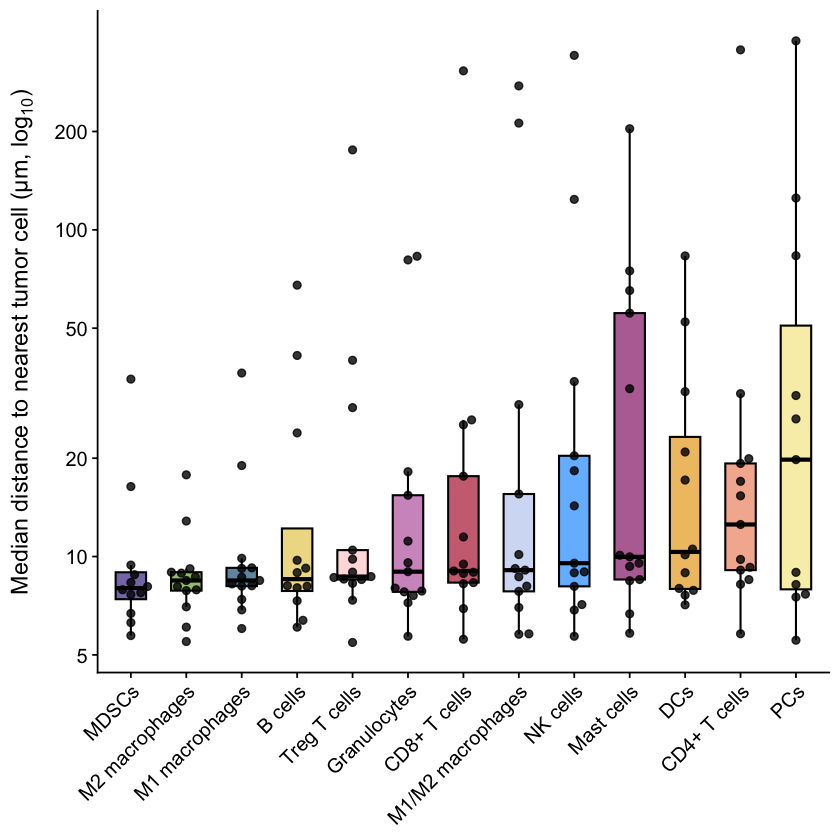

In [20]:
library(ggplot2)
library(dplyr)
library(ggbeeswarm)
library(scales)

# ── Define cells of interest (myeloid + lymphoid) ────────────────────────────
immune_cells <- c(
  "Granulocytes", "M1 macrophages", "M1/M2 macrophages", "M2 macrophages",
  "MDSCs", "DCs", "Mast cells",
  "CD4+ T cells", "CD8+ T cells", "Treg T cells", "B cells", "NK cells", "PCs"
)

plot_df <- distances_scimap_cellcat %>%
  filter(cell_category %in% immune_cells)

# ── Order by median distance ──────────────────────────────────────────────────
order_cells <- plot_df %>%
  group_by(cell_category) %>%
  summarise(med = median(median_distance_um, na.rm = TRUE)) %>%
  arrange(med) %>%
  pull(cell_category)

plot_df$cell_category <- factor(plot_df$cell_category, levels = order_cells)

# ── Plot ──────────────────────────────────────────────────────────────────────
p <- ggplot(plot_df,
            aes(x = cell_category, y = median_distance_um, fill = cell_category)) +

  geom_boxplot(
    width         = 0.55,
    alpha         = 0.65,
    color         = "black",
    outlier.shape = NA
  ) +

  geom_beeswarm(
    cex   = 1.4,
    size  = 1.8,
    alpha = 0.8,
    color = "black"
  ) +

  scale_fill_manual(values = full_palette) +

  scale_y_log10(
    labels = label_number(accuracy = 1),
    breaks = c(5, 10, 20, 50, 100, 200)
  ) +

  labs(
    x = NULL,
    y = expression("Median distance to nearest tumor cell (μm, log"[10]*")")
  ) +

  theme_classic(base_size = 13) +
  theme(
    legend.position = "none",
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 12, colour = "black"),
    axis.text.y     = element_text(size = 12, colour = "black"),
    axis.title.y    = element_text(size = 14, colour = "black", margin = margin(r = 10)),
    axis.line       = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks      = element_line(linewidth = 0.5, colour = "black")
  )

p

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


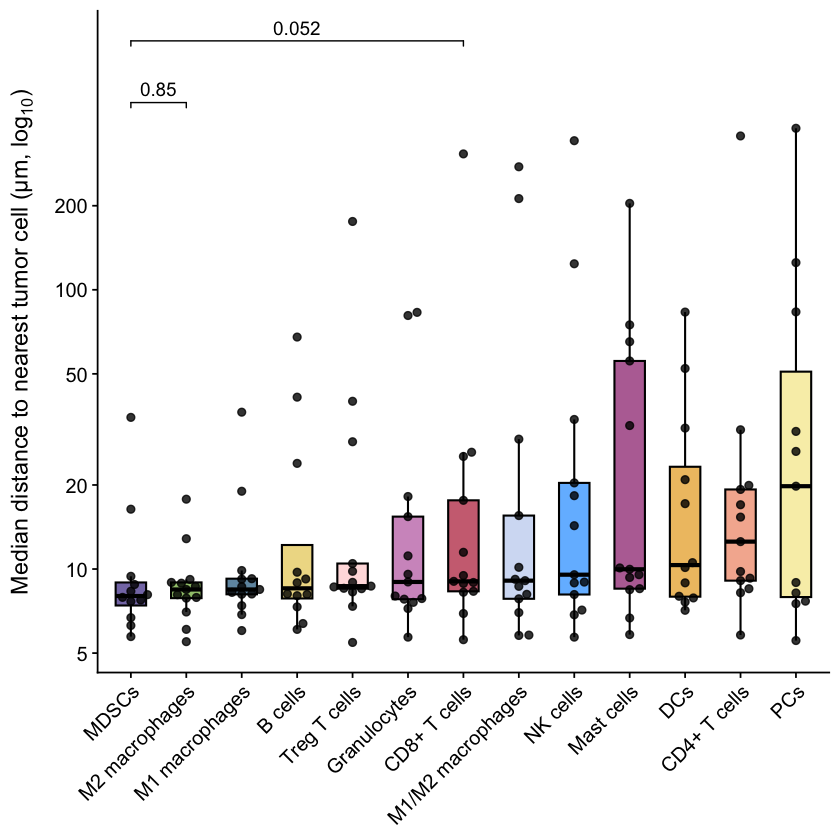

In [16]:
library(ggplot2)
library(dplyr)
library(ggbeeswarm)
library(ggpubr)
library(scales)

# ── Define cells of interest (myeloid + lymphoid) ────────────────────────────
immune_cells <- c(
  "Granulocytes", "M1 macrophages", "M1/M2 macrophages", "M2 macrophages",
  "MDSCs", "DCs", "Mast cells",
  "CD4+ T cells", "CD8+ T cells", "Treg T cells", "B cells", "NK cells", "PCs"
)

plot_df <- distances_scimap_cellcat %>%
  filter(cell_category %in% immune_cells)

# ── Order by median distance ──────────────────────────────────────────────────
order_cells <- plot_df %>%
  group_by(cell_category) %>%
  summarise(med = median(median_distance_um, na.rm = TRUE)) %>%
  arrange(med) %>%
  pull(cell_category)

plot_df$cell_category <- factor(plot_df$cell_category, levels = order_cells)

# ── Comparisons ───────────────────────────────────────────────────────────────
my_comparisons <- list(
  c("MDSCs", "M2 macrophages"),
  c("MDSCs", "CD8+ T cells")
)

# ── Plot ──────────────────────────────────────────────────────────────────────
p <- ggplot(plot_df,
            aes(x = cell_category, y = median_distance_um, fill = cell_category)) +

  geom_boxplot(
    width         = 0.55,
    alpha         = 0.65,
    color         = "black",
    outlier.shape = NA
  ) +

  geom_beeswarm(
    cex   = 1.4,
    size  = 1.8,
    alpha = 0.8,
    color = "black"
  ) +

  stat_compare_means(
    comparisons = my_comparisons,
    method      = "wilcox.test",
    paired      = TRUE,
    label       = "p.format",
    tip.length  = 0.01,
    bracket.size = 0.4,
    size        = 4
  ) +

  scale_fill_manual(values = full_palette) +

  scale_y_log10(
    labels = label_number(accuracy = 1),
    breaks = c(5, 10, 20, 50, 100, 200)
  ) +

  labs(
    x = NULL,
    y = expression("Median distance to nearest tumor cell (μm, log"[10]*")")
  ) +

  theme_classic(base_size = 13) +
  theme(
    legend.position = "none",
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 12, colour = "black"),
    axis.text.y     = element_text(size = 12, colour = "black"),
    axis.title.y    = element_text(size = 14, colour = "black", margin = margin(r = 10)),
    axis.line       = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks      = element_line(linewidth = 0.5, colour = "black")
  )

p

In [ ]:
celltype_metada

In [14]:
distances

patient_exp,patient_ID,cell_category,Cell Center X,Cell Center Y,tumor_signed_dist_to_contour_um,tumor_dist_to_contour_um,tumor_layer,tumor_total_area_um2,non_tumor_area_um2,cell_group
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
NUT_1_ROI1,NUT_1,NFC,2480.7239,4857.791,-18.388312,18.388312,tumor 0-25 µm,286812.3,115224.3,Non-immune
NUT_1_ROI3,NUT_1,Tumor cells,3722.4333,2900.642,-52.009999,52.009999,tumor 25+ µm,1171334.3,184046.8,Tumor
NUT_1_ROI3,NUT_1,Tumor cells,12466.3662,2890.018,-25.500000,25.500000,tumor 25+ µm,1171334.3,184046.8,Tumor
NUT_1_ROI3,NUT_1,Tumor cells,2737.7788,2875.279,-36.776623,36.776623,tumor 25+ µm,1171334.3,184046.8,Tumor
NUT_1_ROI3,NUT_1,Tumor cells,2318.3650,2911.225,-5.100000,5.100000,tumor 0-25 µm,1171334.3,184046.8,Tumor
NUT_1_ROI3,NUT_1,Tumor cells,603.0942,2886.603,-21.027839,21.027839,tumor 0-25 µm,1171334.3,184046.8,Tumor
NUT_1_ROI3,NUT_1,NFC,11714.1533,2903.130,39.832273,39.832273,stroma 25-50 µm,1171334.3,184046.8,Non-immune
NUT_1_ROI3,NUT_1,NFC,9563.5957,2888.619,-14.424978,14.424978,tumor 0-25 µm,1171334.3,184046.8,Non-immune
NUT_1_ROI3,NUT_1,Tumor cells,4836.6763,2890.952,-144.429983,144.429983,tumor 25+ µm,1171334.3,184046.8,Tumor


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“fo

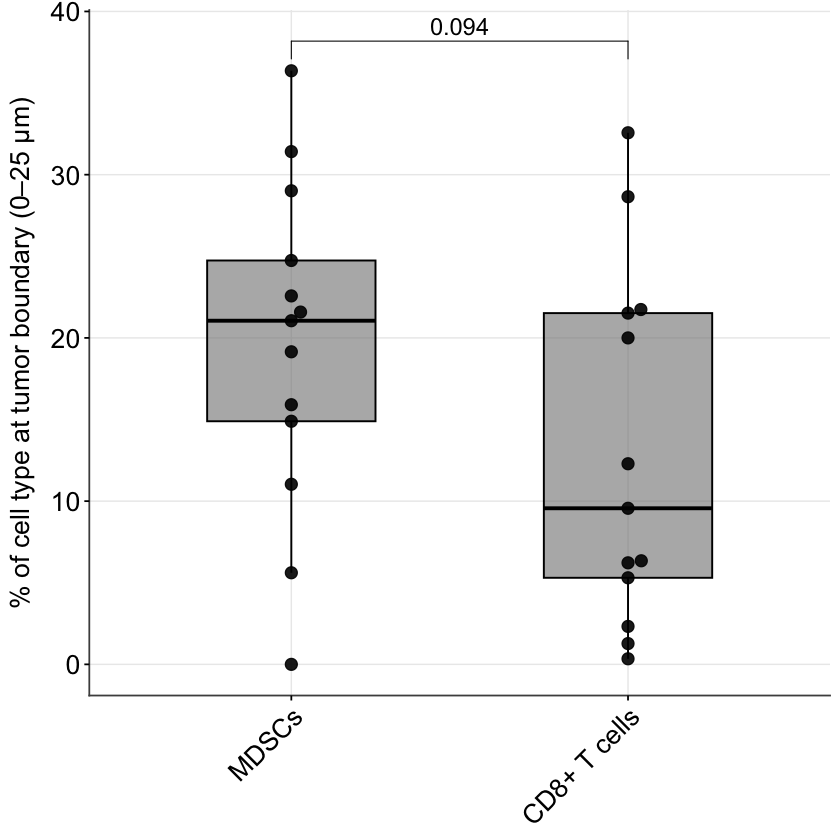

In [19]:
# Step 1: compute fraction of each cell type at the tumor boundary
boundary_compare <- distances %>%
  filter(cell_category %in% c("MDSCs", "CD8+ T cells")) %>%
  group_by(patient_ID, cell_category) %>%
  mutate(total_per_celltype = n()) %>%          # total per cell type per patient (all layers)
  ungroup() %>%
  filter(tumor_layer == "tumor 0-25 µm") %>%    # keep only boundary cells
  group_by(patient_ID, cell_category) %>%
  summarise(
    count              = n(),
    total_per_celltype = first(total_per_celltype),
    percentage         = (count / total_per_celltype) * 100,
    .groups            = "drop"
  ) %>%
  complete(patient_ID, cell_category, fill = list(count = 0, percentage = 0)) %>%
  mutate(
    cell_category = factor(cell_category, levels = c("MDSCs", "CD8+ T cells"))
  )

# Step 2: plot
comparisons <- list(c("MDSCs", "CD8+ T cells"))

ggplot(boundary_compare, aes(x = cell_category, y = percentage, fill = cell_category)) +

  geom_boxplot(
    width         = 0.5,
    alpha         = 0.6,
    color         = "black",
    outlier.shape = NA
  ) +

  geom_beeswarm(
    size  = 3,
    alpha = 0.9,
    color = "black",
    cex   = 2
  ) +

  stat_compare_means(
    comparisons = comparisons,
    method      = "wilcox.test",
    label       = "p.format",
    paired      = TRUE,
    size        = 5
  ) +

  scale_fill_manual(values = c(
    "MDSCs"        = full_palette["MDSCs"],
    "CD8+ T cells" = full_palette["CD8+ T cells"]
  )) +

  labs(
    x = NULL,
    y = "% of cell type at tumor boundary (0–25 µm)"
  ) +

  theme_classic(base_size = 12) +
  theme(
    legend.position  = "none",
    axis.text.x      = element_text(size = 16, colour = "black", angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/mdsc_vs_cd8_boundary_boxplot.pdf"),
       width = 5, height = 6, dpi = 300, bg = "white")

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


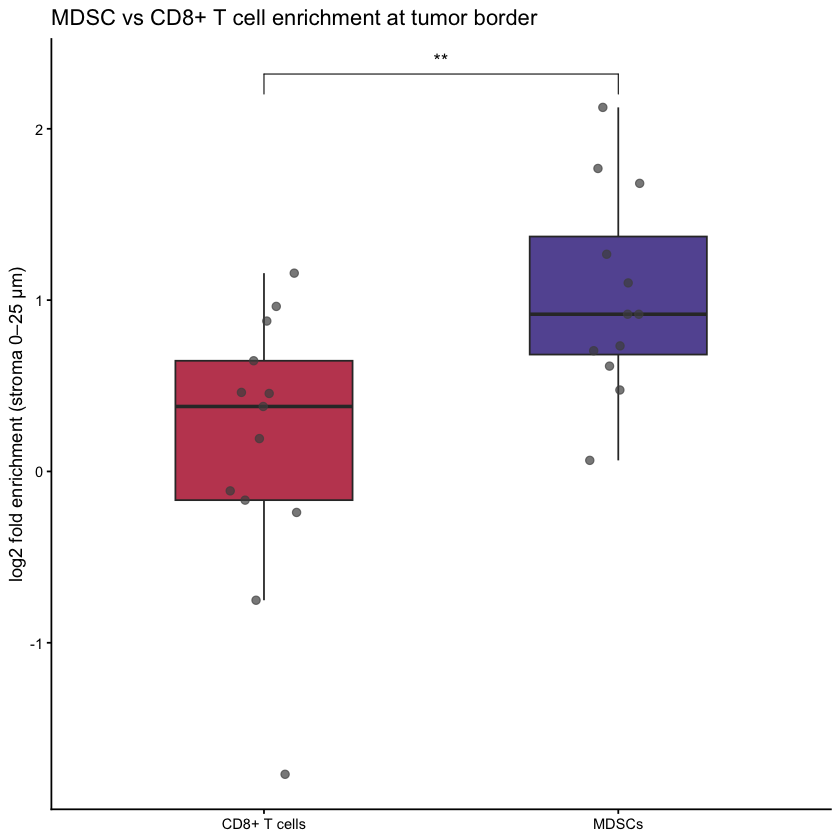

In [13]:

plot_data <- enrich_df %>%
  filter(
    tumor_layer == "stroma 0-25 µm",
    cell_type %in% c("MDSCs", "CD8+ T cells")
  )

ggplot(plot_data, aes(x = cell_type, y = log2_fold_enrichment, fill = cell_type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.8, width = 0.5) +
  geom_jitter(width = 0.1, size = 2, alpha = 0.7, color = "grey30") +
  stat_compare_means(
    comparisons = list(c("MDSCs", "CD8+ T cells")),
    method = "wilcox.test",
    paired = TRUE,
    label = "p.signif"
  ) +
  scale_fill_manual(values = full_palette) +
  labs(
    x = NULL,
    y = "log2 fold enrichment (stroma 0–25 µm)",
    title = "MDSC vs CD8+ T cell enrichment at tumor border"
  ) +
  theme_classic() +
  theme(legend.position = "none")